# 07 - Feature selection with SHAP

Starting from 21 candidate predictors (vegetation indices, weather and soil temperature), this notebook:

1. checks collinearity between candidates,
2. ranks the candidates by mean |SHAP| from an XGBoost model,
3. adds features one at a time in that order and tracks R² on a held-out 20% split,
4. repeats the ranking with a random forest as a check.

The stepwise curve flattens after three features (10-d pcp, EVI median, Rs) and plateaus at seven.
NDVI mean is then dropped from the seven because it is almost collinear with EVI median, which gives
the six-feature set. Both the three- and six-feature sets are evaluated in notebook 08.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [5]:
DATA_DIR = Path("../data/model_input")
FIG_DIR = Path("../results/figures")
TABLE_DIR = Path("../results/tables")

ASP = pd.read_csv(DATA_DIR / "ASP_model_input.csv")
BAU = pd.read_csv(DATA_DIR / "BAU_model_input.csv")
df = pd.concat([ASP, BAU])

TARGET = "ETa"
CANDIDATES = [
    "NDVI Mean", "EVI Mean", "SAVI Mean", "MSAVI Mean", "NDWI Mean",
    "NDVI Median", "EVI Median", "SAVI Median", "MSAVI Median", "NDWI Median",
    "DOY", "Tmax", "Tmin", "RHmax", "RHmin", "Ts", "U", "Rs",
    "ASCE ETr", "Pcp", "10-d pcp",
]
print(df.shape)

(3467, 35)


## Correlation between candidates (Supplementary Fig. S2)

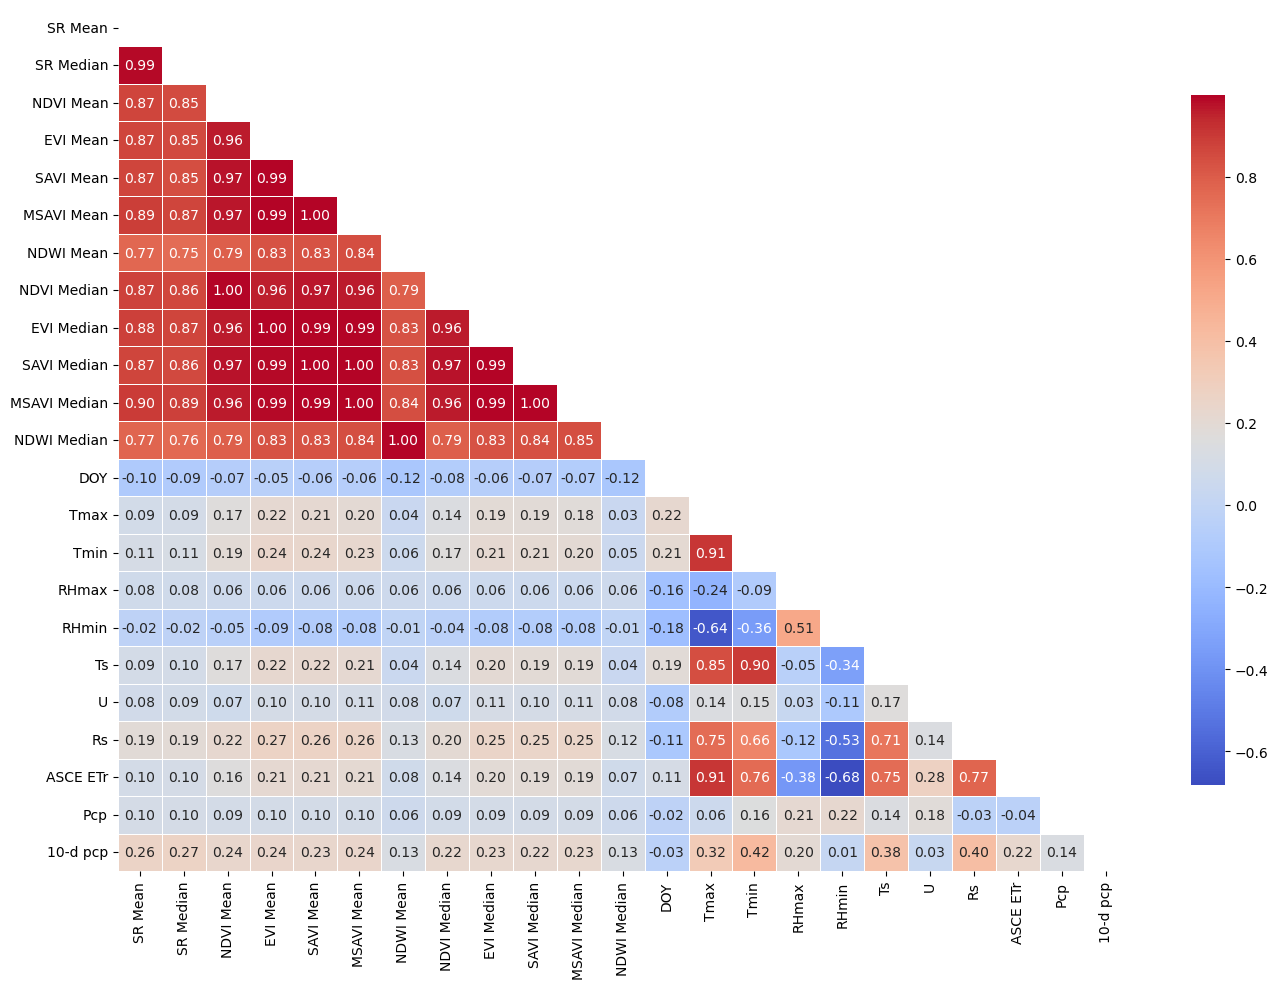

r(EVI Median, NDVI Mean) = 0.96


In [6]:
cols = ["SR Mean", "SR Median"] + CANDIDATES
corr = df[cols].apply(pd.to_numeric, errors="coerce").corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), cmap="coolwarm",
            annot=True, fmt=".2f", linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.tight_layout()
plt.savefig(FIG_DIR / "supp_fig_s2_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

print("r(EVI Median, NDVI Mean) =", round(corr.loc["EVI Median", "NDVI Mean"], 2))

## SHAP ranking and stepwise feature addition (Fig. 5)

SHAP values are computed on the training part only. XGBoost handles the missing values in the
candidate columns natively, so no rows are dropped here.

In [7]:
X = df[CANDIDATES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(objective="reg:squarederror")
model.fit(X_train, y_train)
shap_values = shap.Explainer(model)(X_train)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
ranking = X_train.columns[np.argsort(mean_abs_shap)[::-1]]
print("SHAP ranking:", list(ranking))

SHAP ranking: ['10-d pcp', 'EVI Median', 'Rs', 'Tmin', 'NDVI Mean', 'RHmax', 'Pcp', 'EVI Mean', 'Ts', 'DOY', 'U', 'RHmin', 'ASCE ETr', 'NDVI Median', 'NDWI Median', 'Tmax', 'SAVI Median', 'NDWI Mean', 'SAVI Mean', 'MSAVI Mean', 'MSAVI Median']


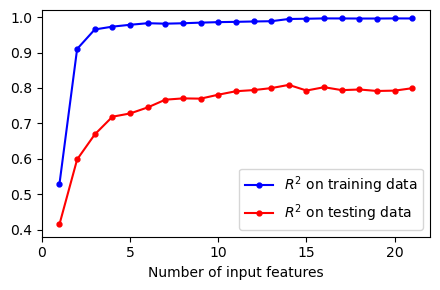

In [8]:
r2_train, r2_test = [], []
for k in range(1, len(ranking) + 1):
    feats = ranking[:k]
    m = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
    m.fit(X_train[feats], y_train)
    r2_train.append(r2_score(y_train, m.predict(X_train[feats])))
    r2_test.append(r2_score(y_test, m.predict(X_test[feats])))

n = np.arange(1, len(ranking) + 1)
plt.figure(figsize=(4.5, 3))
plt.plot(n, r2_train, "-o", color="blue", markersize=3.5, label="$R^2$ on training data")
plt.plot(n, r2_test, "-o", color="red", markersize=3.5, label="$R^2$ on testing data")
plt.ylim(0.38, 1.02)
plt.yticks(np.arange(0.4, 1.01, 0.1))
plt.xlim(0, len(ranking) + 1)
plt.xticks(np.arange(0, len(ranking) + 1, 5))
plt.xlabel("Number of input features")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_stepwise_feature_r2.png", dpi=300, bbox_inches="tight")
plt.show()

pd.DataFrame({"n_features": n, "added": ranking, "r2_train": r2_train, "r2_test": r2_test}) \
  .to_csv(TABLE_DIR / "stepwise_feature_selection.csv", index=False)

## Global and local SHAP plot, top 15 features (Fig. 4)

This figure uses a separate XGBoost fit with 250 trees.

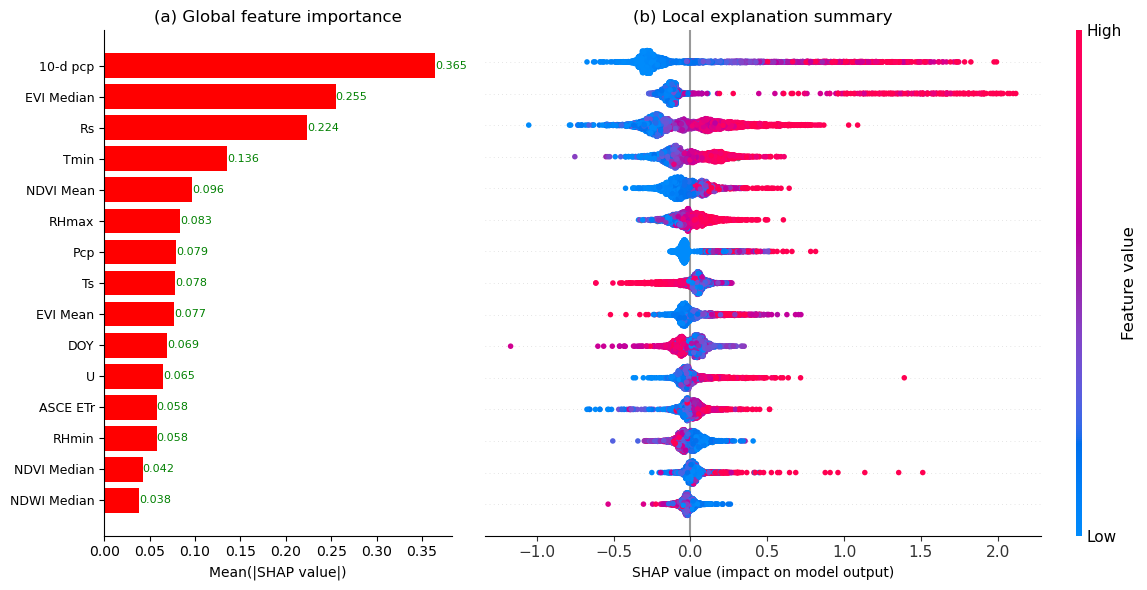

In [9]:
model_250 = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=250, random_state=42)
model_250.fit(X_train, y_train)
sv = shap.Explainer(model_250)(X_train)

mean_abs = np.abs(sv.values).mean(axis=0)
top_n = 15
top_idx = np.argsort(mean_abs)[::-1][:top_n]
top_features = X_train.columns[top_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [1, 2]})

bars = ax1.barh(top_features, mean_abs[top_idx], color="red")
ax1.invert_yaxis()
ax1.set_title("(a) Global feature importance", fontsize=12)
ax1.set_xlabel("Mean(|SHAP value|)", fontsize=10)
ax1.tick_params(axis="y", labelsize=9)
for bar, val in zip(bars, mean_abs[top_idx]):
    ax1.text(val + 1e-4, bar.get_y() + bar.get_height() / 2, f"{val:.3f}",
             va="center", ha="left", color="green", fontsize=8)

shap.plots.beeswarm(sv[:, top_idx], max_display=top_n, ax=ax2, show=False, plot_size=None)
ax2.set_title("(b) Local explanation summary", fontsize=12)
ax2.set_xlabel("SHAP value (impact on model output)", fontsize=10)
ax2.set_yticklabels([])   # feature names are already on the left panel

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_shap_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## Same analysis with a random forest (Supplementary Fig. S1)

A check that the ranking is not specific to XGBoost. The SHAP step for a 500-tree forest is slow
(about 20 minutes on a laptop).

100%|===================| 2771/2773 [18:30<00:00]        

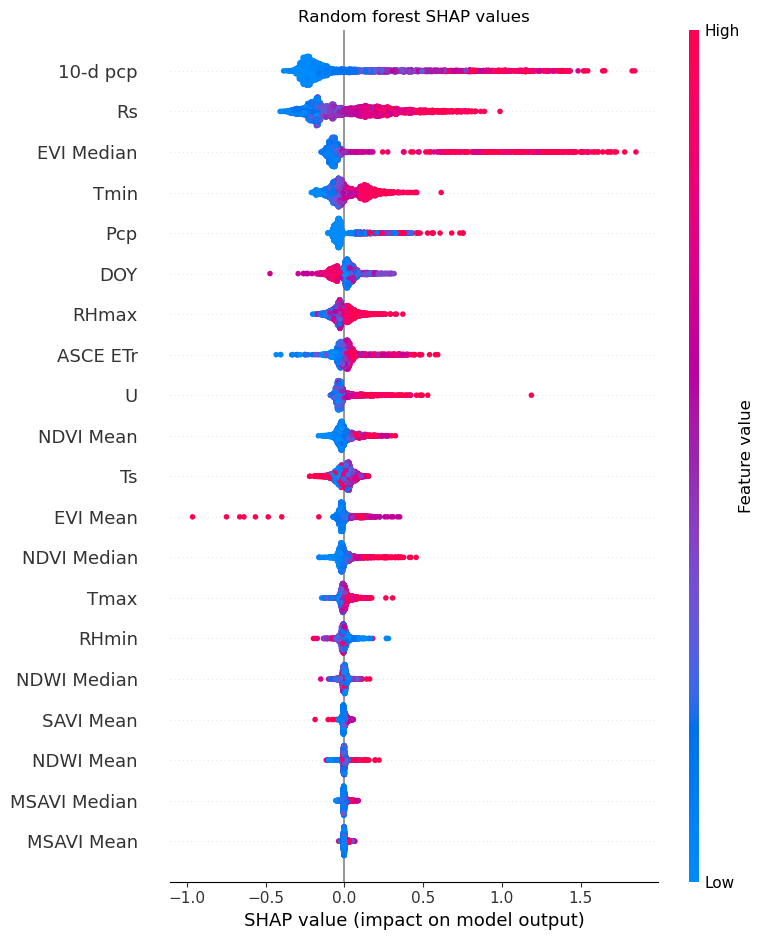

RF SHAP ranking: ['10-d pcp', 'Rs', 'EVI Median', 'Tmin', 'Pcp', 'DOY', 'RHmax', 'ASCE ETr', 'U', 'NDVI Mean', 'Ts', 'EVI Mean', 'NDVI Median', 'Tmax', 'RHmin', 'NDWI Median', 'SAVI Mean', 'NDWI Mean', 'MSAVI Median', 'MSAVI Mean', 'SAVI Median']


In [10]:
rf = RandomForestRegressor(n_estimators=500, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
sv_rf = shap.Explainer(rf, X_train)(X_train)

shap.summary_plot(sv_rf, X_train, max_display=20, show=False)
plt.title("Random forest SHAP values")
plt.tight_layout()
plt.savefig(FIG_DIR / "supp_fig_s1_shap_rf.png", dpi=300, bbox_inches="tight")
plt.show()

ranking_rf = X_train.columns[np.argsort(np.abs(sv_rf.values).mean(axis=0))[::-1]]
print("RF SHAP ranking:", list(ranking_rf))

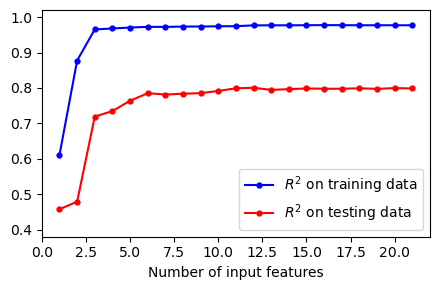

In [11]:
r2_train_rf, r2_test_rf = [], []
for k in range(1, len(ranking_rf) + 1):
    feats = ranking_rf[:k]
    m = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
    m.fit(X_train[feats], y_train)
    r2_train_rf.append(r2_score(y_train, m.predict(X_train[feats])))
    r2_test_rf.append(r2_score(y_test, m.predict(X_test[feats])))

n = np.arange(1, len(ranking_rf) + 1)
plt.figure(figsize=(4.5, 3))
plt.plot(n, r2_train_rf, "-o", color="blue", markersize=3.5, label="$R^2$ on training data")
plt.plot(n, r2_test_rf, "-o", color="red", markersize=3.5, label="$R^2$ on testing data")
plt.ylim(0.38, 1.02)
plt.xlabel("Number of input features")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "supp_stepwise_feature_r2_rf.png", dpi=300, bbox_inches="tight")
plt.show()

## Descriptive statistics of the weather variables (Supplementary Table S1)

In [13]:
clim = pd.read_csv("../data/raw/climate/CoAgMet_Climatic_Data.csv")
clim["Date"] = pd.to_datetime(clim["Date"])
desc = clim[clim["Date"] >= "2018-01-01"].describe()
desc.to_csv(TABLE_DIR / "supp_table_s1_weather_stats.csv")
desc.round(2)

,Date,DOY,Tavg,Tmax,Tmin,RHmax,RHmin,Rs,Precipitation,3-d pcp,5-d pcp,7-d pcp,10-d pcp,U,ASCE ETr,PK ET,ASCE Hourly ET,5cm Soil Max Temp,5cm Soil Min Temp,Ts
count,2846,2846.00,2836.00,2836.00,2836.00,2835.00,2836.00,2836.00,2838.00,2843.00,2845.00,2845.00,2846.00,2821.00,2834.00,2834.00,2830.00,2826.00,2825.00,2823.00
mean,2021-11-23 12:00:00,179.27,9.89,18.47,1.88,0.88,0.31,190.19,1.03,-0.44,-1.90,-2.66,10.23,11.16,6.14,5.03,5.13,15.19,10.46,12.75
min,2018-01-01 00:00:00,1.00,-25.05,-20.82,-31.42,0.30,0.00,14.10,0.00,-2997.00,-3993.46,-3993.46,0.00,0.00,0.17,0.00,0.08,-7.12,-273.20,-8.24
25%,2019-12-13 06:00:00,89.25,1.32,9.63,-5.88,0.81,0.16,114.93,0.00,0.00,0.00,0.00,0.00,8.45,3.06,2.07,2.28,3.65,1.09,2.41
50%,2021-11-23 12:00:00,178.00,9.87,19.19,1.17,0.91,0.24,190.28,0.00,0.00,0.25,1.02,2.54,10.37,5.88,4.51,4.73,14.54,9.64,12.16
75%,2023-11-04 18:00:00,267.00,19.53,28.71,11.16,0.98,0.40,261.63,0.00,1.52,4.07,7.36,13.20,13.25,8.88,7.57,7.61,25.22,19.74,22.55
max,2025-10-16 00:00:00,366.00,30.66,39.39,23.17,1.04,1.01,366.78,60.45,75.19,75.19,84.83,102.61,35.33,50.79,27.74,19.55,711.00,45.74,93.17
std,NaN,104.08,10.72,11.87,10.09,0.13,0.20,83.97,4.29,88.28,138.04,174.13,16.40,3.72,3.79,3.30,3.32,17.91,10.89,10.76
